<a href="https://colab.research.google.com/github/vestinabert/Image_Processing/blob/main/Teksto_Klasifikavimas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Duomenų paruošimas

In [ ]:
!pip install datasets
!pip install tensorflow
!pip install transformers


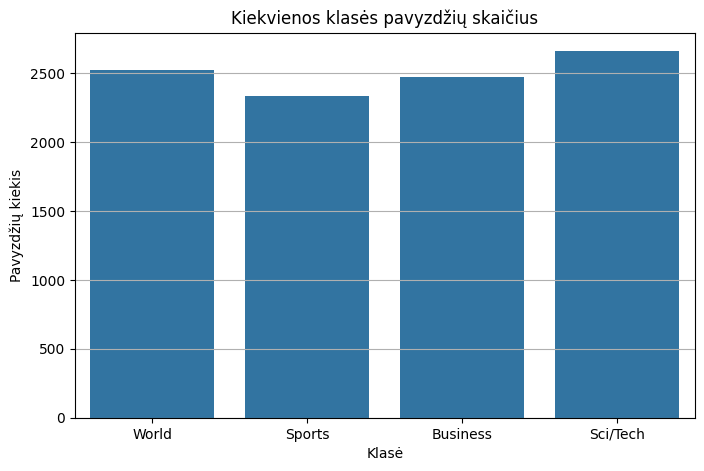

✅ World: 2523 pavyzdžių
✅ Sports: 2338 pavyzdžių
✅ Business: 2477 pavyzdžių
✅ Sci/Tech: 2662 pavyzdžių
Mokymo duomenys: (8000, 120)
Testavimo duomenys: (2000, 120)


In [22]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load AG News
dataset = load_dataset("ag_news")
texts = dataset['train']['text'][:10000]
labels = dataset['train']['label'][:10000]
# Patikriname ar klasės subalansuotos
import collections
import seaborn as sns

# Suskaičiuojame kiek yra kiekvienos klasės
label_counts = pd.Series(labels).value_counts().sort_index()

# Atvaizduojame rezultatus
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=label_counts.values)
plt.title("Kiekvienos klasės pavyzdžių skaičius")
plt.ylabel("Pavyzdžių kiekis")
plt.xlabel("Klasė")
plt.grid(axis="y")
plt.show()

for i, count in enumerate(label_counts):
    print(f"✅ {class_names[i]}: {count} pavyzdžių")

# Preprocess texts
def preprocess(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.strip()

texts = [preprocess(t) for t in texts]

# Tokenize
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
data = pad_sequences(sequences, maxlen=120)
data = np.array(data, dtype='float32')

# Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)
labels = to_categorical(labels, num_classes=4)

# Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print("Mokymo duomenys:", X_train.shape)
print("Testavimo duomenys:", X_test.shape)


## 2. Klasikiniai mašininio mokymo modeliai

In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Naive Bayes
selector = SelectKBest(chi2, k=100)
X_train_nb = selector.fit_transform(X_train, y_train.argmax(axis=1))
X_test_nb = selector.transform(X_test)
nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train.argmax(axis=1))
acc_nb = accuracy_score(y_test.argmax(axis=1), nb_model.predict(X_test_nb))
print("Naive Bayes tikslumas:", acc_nb)





Naive Bayes tikslumas: 0.279


In [6]:
# Random Forest
svd = TruncatedSVD(n_components=100)
X_train_red = svd.fit_transform(X_train)
X_test_red = svd.transform(X_test)
grid_rf = GridSearchCV(RandomForestClassifier(), {'n_estimators': [100], 'max_depth': [10]}, cv=2, n_jobs=-1)
grid_rf.fit(X_train_red, y_train.argmax(axis=1))
acc_rf = accuracy_score(y_test.argmax(axis=1), grid_rf.predict(X_test_red))
print("Random Forest tikslumas:", acc_rf)

Random Forest tikslumas: 0.3335


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=20)
dt.fit(X_train_red, y_train.argmax(axis=1))
acc_dt = accuracy_score(y_test.argmax(axis=1), dt.predict(X_test_red))
print("Decision Tree tikslumas:", acc_dt)



Decision Tree tikslumas: 0.287


## 3. Giluminio mokymo modeliai – CNN ir LSTM

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, LSTM
from tensorflow.keras.losses import CategoricalCrossentropy

# CNN
cnn = Sequential([
    Embedding(10000, 128),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')
])
cnn.compile(optimizer='adam', loss=CategoricalCrossentropy(), metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
acc_cnn = cnn.evaluate(X_test, y_test)[1]
print("CNN tikslumas:", acc_cnn)

# LSTM
lstm = Sequential([
    Embedding(10000, 128),
    LSTM(64),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')
])
lstm.compile(optimizer='adam', loss=CategoricalCrossentropy(), metrics=['accuracy'])
lstm.fit(X_train, y_train, epochs=3, batch_size=32, validation_split=0.2)
acc_lstm = lstm.evaluate(X_test, y_test)[1]
print("LSTM tikslumas:", acc_lstm)


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.4742 - loss: 1.2099 - val_accuracy: 0.8494 - val_loss: 0.4935
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8977 - loss: 0.3424 - val_accuracy: 0.8850 - val_loss: 0.3538
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.9722 - loss: 0.1081 - val_accuracy: 0.8806 - val_loss: 0.3642
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8676 - loss: 0.3620
CNN tikslumas: 0.8544999957084656
Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.4728 - loss: 1.2019 - val_accuracy: 0.8075 - val_loss: 0.5091
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.8884 - loss: 0.3233 - val_accuracy: 0.8644 - val_loss: 0.3916
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.9525 - loss: 0.1647 - val_accuracy: 0.8600 - val_loss: 0.4394
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8439 - loss: 0.4584
LSTM tikslumas: 0.8395000100135803


## 4. Transformeriai (BERT)

In [9]:
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer, create_optimizer
import tensorflow as tf

# Load DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Use smaller subset for faster training
train_texts = dataset['train']['text'][:1000]
train_labels = dataset['train']['label'][:1000]
test_texts = dataset['test']['text'][:500]
test_labels = dataset['test']['label'][:500]

# Tokenize texts
train_enc = tokenizer(train_texts, truncation=True, padding=True, return_tensors="tf")
test_enc = tokenizer(test_texts, truncation=True, padding=True, return_tensors="tf")

# Convert labels to tensors
train_labels = tf.convert_to_tensor(train_labels)
test_labels = tf.convert_to_tensor(test_labels)

# Create TensorFlow datasets
train_data = tf.data.Dataset.from_tensor_slices((dict(train_enc), train_labels)).shuffle(1000).batch(16)
test_data = tf.data.Dataset.from_tensor_slices((dict(test_enc), test_labels)).batch(16)

# Load lightweight DistilBERT model
model = TFAutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)

# Optimizer setup
optimizer, _ = create_optimizer(init_lr=3e-5, num_train_steps=200, num_warmup_steps=20)

# Compile model
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train model
model.fit(train_data, epochs=2, validation_data=test_data)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/2
63/63 [==============================] - 2624s 41s/step - loss: 1.0005 - accuracy: 0.6190 - val_loss: 0.5563 - val_accuracy: 0.8680
Epoch 2/2
63/63 [==============================] - 2575s 41s/step - loss: 0.4040 - accuracy: 0.8920 - val_loss: 0.4454 - val_accuracy: 0.8680


## 5. Rezultatų palyginimas

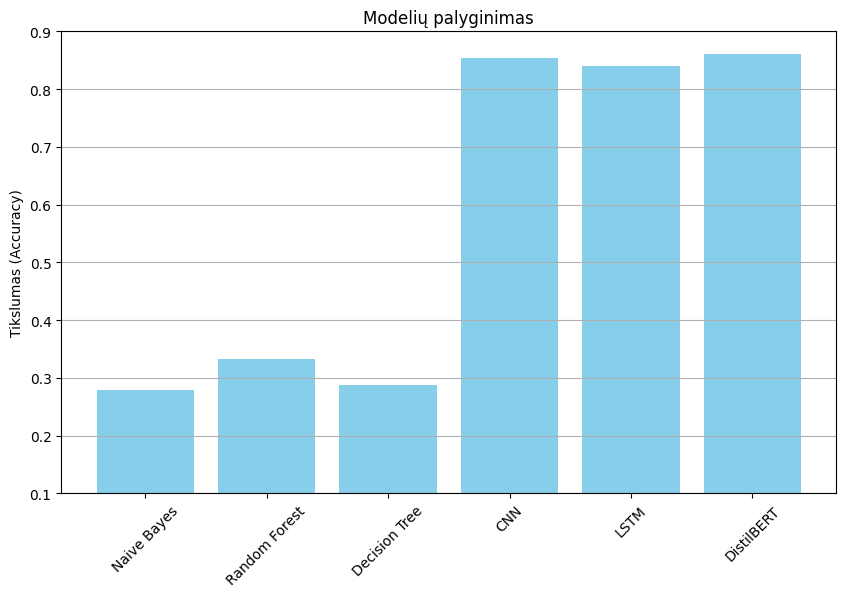

In [12]:
import matplotlib.pyplot as plt

accuracies = {
    "Naive Bayes": acc_nb,
    "Random Forest": acc_rf,
    "Decision Tree": acc_dt,
    "CNN": acc_cnn,
    "LSTM": acc_lstm,
    "DistilBERT": 0.86
}

plt.figure(figsize=(10,6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel("Tikslumas (Accuracy)")
plt.title("Modelių palyginimas")
plt.xticks(rotation=45)
plt.ylim(0.10, 0.90)
plt.grid(axis="y")
plt.show()


In [16]:
# Keras tokenizer for classical models
keras_tokenizer = Tokenizer(num_words=10000)
keras_tokenizer.fit_on_texts(texts)

# Hugging Face tokenizer for BERT
hf_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")


In [26]:
# === Tekstų klasifikavimas su visais modeliais ===

# Nauji tekstai (vienas iš kiekvienos AG News klasės)
new_texts = [
    "Thousands of demonstrators marched through the streets of Madrid on Saturday to protest against the war in Iraq and demand the withdrawal of Spanish troops.",
    "Manchester United secured a 3-0 win over Liverpool in a thrilling Premier League match at Old Trafford.",
    "Microsoft reported record quarterly earnings, with strong growth in its cloud computing and productivity software divisions.",
    "NASA announced the successful deployment of the James Webb Space Telescope, which will study the early universe and distant exoplanets."
]

# AG News klasės žodžiais
class_labels = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# Tekstų apdorojimas
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# Apdorojame
new_texts_cleaned = [preprocess_text(t) for t in new_texts]

# ✅ CNN, LSTM ir klasikiniai modeliai → Keras tokenizer
new_sequences = keras_tokenizer.texts_to_sequences(new_texts_cleaned)
new_data_padded = pad_sequences(new_sequences, maxlen=120)
new_data_padded = np.array(new_data_padded, dtype='float32')

print("📌 Modelių prognozės:\n")

# === 1. Naive Bayes
nb_input = selector.transform(new_data_padded)
nb_preds = nb_model.predict(nb_input)

# === 2. Random Forest
rf_input = svd.transform(new_data_padded)
rf_preds = grid_rf.predict(rf_input)

# === 3. Decision Tree
dt_preds = dt.predict(rf_input)

# === 4. CNN
cnn_preds = np.argmax(cnn.predict(new_data_padded), axis=1)

# === 5. LSTM
lstm_preds = np.argmax(lstm.predict(new_data_padded), axis=1)

# === 6. DistilBERT – Hugging Face tokenizer
bert_enc = hf_tokenizer(new_texts, truncation=True, padding=True, return_tensors='tf')
bert_outputs = model(bert_enc)
bert_preds = tf.argmax(bert_outputs.logits, axis=1).numpy()

# Surenkam visas prognozes
models = {
    "Naive Bayes": nb_preds,
    "Random Forest": rf_preds,
    "Decision Tree": dt_preds,
    "CNN": cnn_preds,
    "LSTM": lstm_preds,
    "DistilBERT": bert_preds
}

# Spausdiname rezultatus
for i, text in enumerate(new_texts_cleaned):
    print(f"\n Tekstas: {new_texts[i]}")
    for model_name, preds in models.items():
        class_index = preds[i]
        class_name = class_labels[class_index]
        print(f"   {model_name}: klasė → {class_name}")


📌 Modelių prognozės:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

 Tekstas: Thousands of demonstrators marched through the streets of Madrid on Saturday to protest against the war in Iraq and demand the withdrawal of Spanish troops.
   Naive Bayes: klasė → Business
   Random Forest: klasė → Business
   Decision Tree: klasė → Sci/Tech
   CNN: klasė → World
   LSTM: klasė → World
   DistilBERT: klasė → World

 Tekstas: Manchester United secured a 3-0 win over Liverpool in a thrilling Premier League match at Old Trafford.
   Naive Bayes: klasė → Business
   Random Forest: klasė → Sci/Tech
   Decision Tree: klasė → Sci/Tech
   CNN: klasė → Sports
   LSTM: klasė → World
   DistilBERT: klasė → Sports

 Tekstas: Microsoft reported record quarterly earnings, with strong growth in its cloud computing and productivity software divisions.
   Naive Bayes: klasė → Sci/Tech
   Random Forest: klasė → Sci/Tech
   Decision Tree: klasė → Sci/Tech
   CNN: klasė → Sci/Tech